<a href="https://colab.research.google.com/github/brucnsilva/topicos-de-big-data-em-phyton-pub/blob/main/versao%20final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from google.colab import files

In [5]:
print("Selecione o arquivo BaseMunicipioMensal (1).csv:")
uploaded = files.upload()

Selecione o arquivo BaseMunicipioMensal (1).csv:


Saving BaseMunicipioMensal (1).csv to BaseMunicipioMensal (1).csv


In [6]:
df = pd.read_csv('BaseMunicipioMensal (1).csv', sep=';', encoding='latin-1')

In [7]:
colunas_desejadas = [
    'fmun',
    'ano',
    'mes',
    'regiao',
    'roubo_veiculo',
    'furto_veiculos',
    'trafico_drogas',
    'recuperacao_veiculos'
]

In [8]:
df_filtrado = df[colunas_desejadas]

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ler a planilha CSV
df = pd.read_csv('planilha_filtrada_base_municipal (1).csv', sep=';')

# Criar a variável Y = roubo_veiculo + furto_veiculos
df['total_veiculos'] = df['roubo_veiculo'] + df['furto_veiculos']

# Agrupar por ano e somar os valores
dados_ano = df.groupby('ano')['total_veiculos'].sum().reset_index()

# Variável independente (X)
x = dados_ano['ano'].values

# Variável dependente (Y)
y = dados_ano['total_veiculos'].values

# Calcula a regressão linear simples
coeficiente_angular, intercepto = np.polyfit(x, y, 1)

# Exibir coeficientes
print(f'Coeficiente Angular: {coeficiente_angular}')
print(f'Intercepto: {intercepto}')

Coeficiente Angular: -2766.862637362758
Intercepto: 5635494.142857387


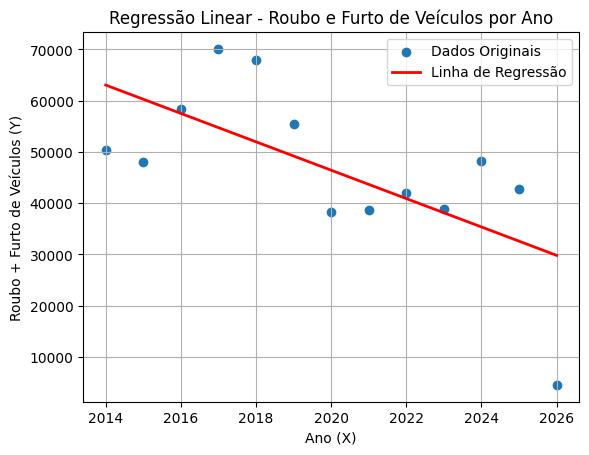

In [13]:
# Criar previsões usando a equação da regressão
y_pred = coeficiente_angular * x + intercepto

# Plotar os dados e a linha de regressão
plt.scatter(x, y, label='Dados Originais')

plt.plot(
    x,
    y_pred,
    color='red',
    linewidth=2,
    label='Linha de Regressão'
)

plt.xlabel('Ano (X)')
plt.ylabel('Roubo + Furto de Veículos (Y)')
plt.legend()

plt.title('Regressão Linear - Roubo e Furto de Veículos por Ano')

plt.grid(True)
plt.show()

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# Criar variável com a soma
df["total_veiculos"] = df["roubo_veiculo"] + df["furto_veiculos"]

# Agrupar por região e somar os veículos
distribuicao = df.groupby("regiao")["total_veiculos"].sum()

# Transformar em arrays numpy
regioes = distribuicao.index.values
frequencias = distribuicao.values

# Frequência relativa (%)
freq_relativa = frequencias / np.sum(frequencias) * 100

# Frequência acumulada
freq_acumulada = np.cumsum(frequencias)

# Frequência relativa acumulada
freq_rel_acumulada = np.cumsum(freq_relativa)

# Criar DataFrame final
tabela_freq = pd.DataFrame({
    "Região": regioes,
    "Frequência Absoluta (f)": frequencias,
    "Frequência Relativa (%)": np.round(freq_relativa, 2),
    "Frequência Acumulada (F)": freq_acumulada,
    "Freq. Rel. Acumulada (%)": np.round(freq_rel_acumulada, 2)
})

# Mostrar tabela
print("\nDistribuição de Frequência:\n")
print(tabela_freq)


Distribuição de Frequência:

               Região  Frequência Absoluta (f)  Frequência Relativa (%)  \
0  Baixada Fluminense                   182476                    30.23   
1             Capital                   289794                    48.01   
2      Grande Niterói                    78061                    12.93   
3            Interior                    53280                     8.83   

   Frequência Acumulada (F)  Freq. Rel. Acumulada (%)  
0                    182476                     30.23  
1                    472270                     78.24  
2                    550331                     91.17  
3                    603611                    100.00  


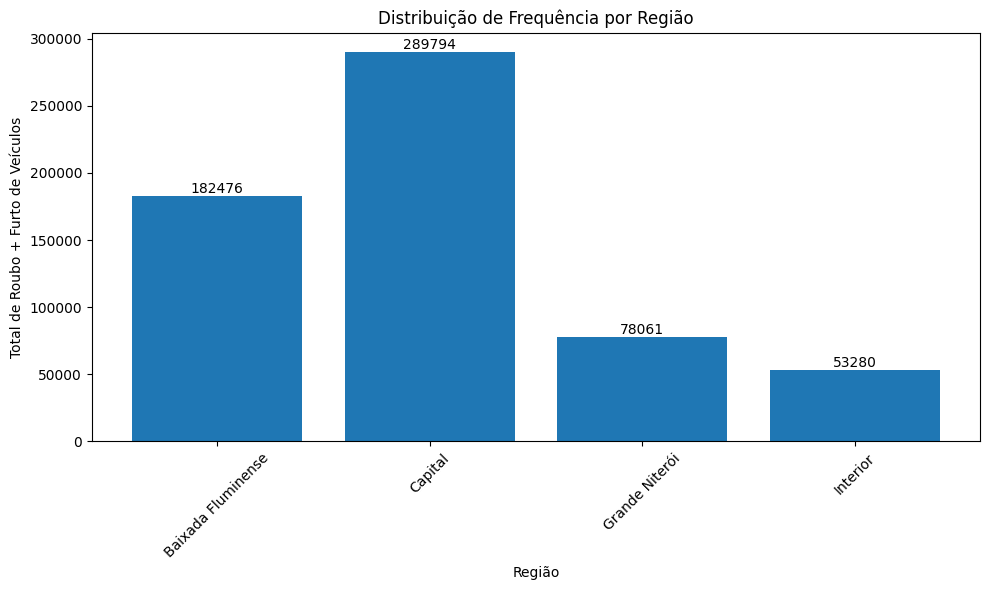

In [21]:
plt.figure(figsize=(10,6))

plt.bar(regioes, frequencias)

plt.title("Distribuição de Frequência por Região")
plt.xlabel("Região")
plt.ylabel("Total de Roubo + Furto de Veículos")

# Mostrar valores em cima das barras
for i, valor in enumerate(frequencias):
    plt.text(i, valor, str(valor), ha='center', va='bottom')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [32]:
import seaborn as sns

df['total_veiculos'] = (
    df['roubo_veiculo'] +
    df['furto_veiculos']
)

# Agrupar por região e somar total de veículos
dados_regiao = df.groupby('regiao')['total_veiculos'].sum()

# Transformar em array numpy
data = dados_regiao.values

# Calcular score-z
zscores = np.abs(
    (data - np.mean(data))
    / np.std(data)
)

# Criar DataFrame final
resultado = pd.DataFrame({
    'regiao': dados_regiao.index,
    'total_veiculos': data,
    'z_score': zscores
})

# Mostrar resultados
print("\nSCORES-Z POR REGIÃO:\n")

print(resultado)

# Identificar outliers
outliers = resultado[resultado['z_score'] > 3]

print("\nOUTLIERS IDENTIFICADOS:\n")

print(outliers)


SCORES-Z POR REGIÃO:

               regiao  total_veiculos   z_score
0  Baixada Fluminense          182476  0.336937
1             Capital          289794  1.482191
2      Grande Niterói           78061  0.777338
3            Interior           53280  1.041791

OUTLIERS IDENTIFICADOS:

Empty DataFrame
Columns: [regiao, total_veiculos, z_score]
Index: []
